## Outliers validations

In [3]:
import pandas as pd
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/raw/diabetes_prediction_dataset.csv")

### Feature Analysis

The dataset contains several categorical features, including:

- Gender  
- Hypertension  
- Heart Disease  
- Smoking History  
- Diabetes  

Since these variables are categorical, they do not require outlier detection. Outlier analysis is typically applied to numerical features, where extreme values may impact the model.

### Boxplot Visualization

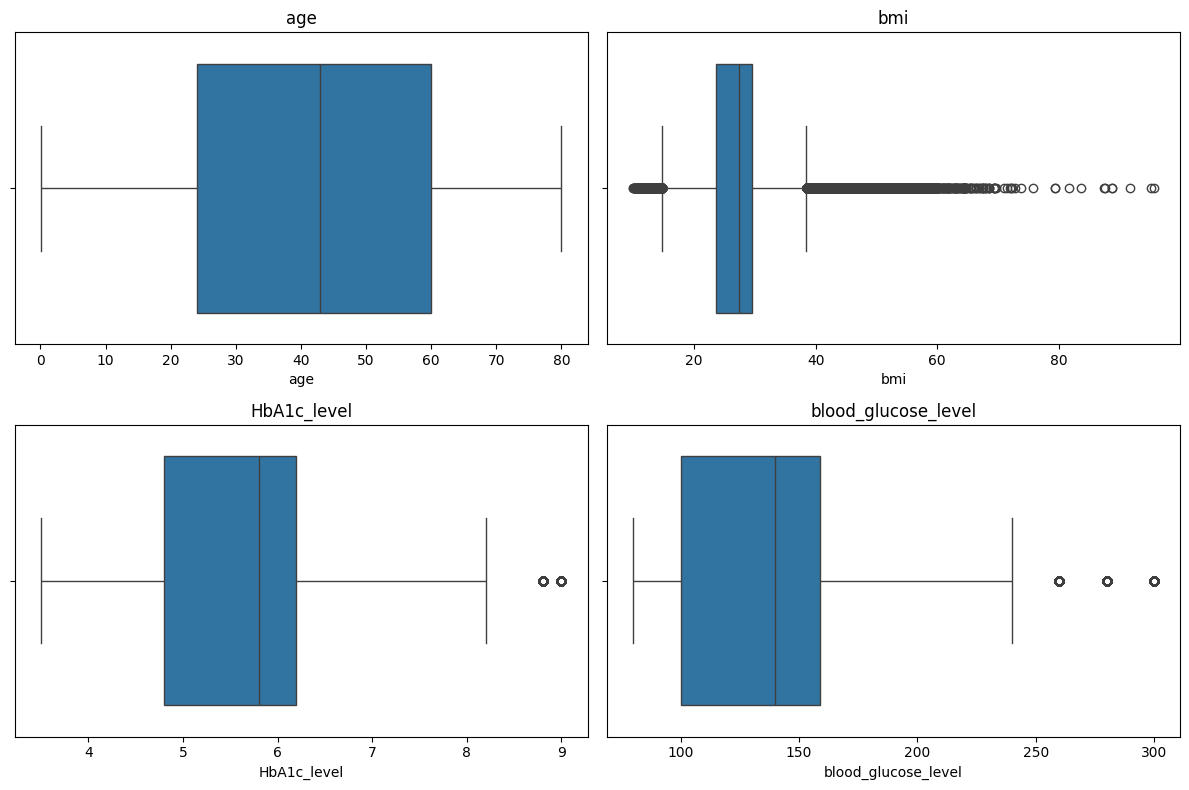

In [5]:
cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

plt.figure(figsize=(12, 8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)  # 2 rows, 2 columns
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [9]:
### IQR Report

In [ ]:
cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']


def flag_iqr_outliers(df, cols):
    results = {}
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        mask = (df[col] < lower) | (df[col] > upper)
        results[col] = {
            'lower': lower,
            'upper': upper,
            'n_outliers': mask.sum()
        }
    return results

def print_iqr_report(df, cols):
    results = flag_iqr_outliers(df, cols)
    W = 62
    SEP = "─" * W

    print(f"\n{'═' * W}")
    print(f"  IQR OUTLIER DETECTION REPORT")
    print(f"  Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"{'═' * W}")

    total_outlier_rows = set()

    for col, r in results.items():
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        mask = (df[col] < r['lower']) | (df[col] > r['upper'])
        outlier_idx = df.index[mask].tolist()
        total_outlier_rows.update(outlier_idx)
        pct = mask.mean() * 100

        print(f"\n  Column : {col}")
        print(f"  {SEP}")
        print(f"  {'Q1':<22} {Q1:>10.2f}")
        print(f"  {'Q3':<22} {Q3:>10.2f}")
        print(f"  {'IQR':<22} {IQR:>10.2f}")
        print(f"  {'Lower fence':<22} {r['lower']:>10.2f}")
        print(f"  {'Upper fence':<22} {r['upper']:>10.2f}")
        print(f"  {'Outliers found':<22} {r['n_outliers']:>10}  ({pct:.2f}%)")

        if r['n_outliers'] > 0:
            vals = df.loc[mask, col].values
            preview = ", ".join(f"{v:.2f}" for v in vals[:8])
            if len(vals) > 8:
                preview += f"  ... +{len(vals)-8} more"
            print(f"  {'Values':<22} {preview}")

    print(f"\n{'═' * W}")
    print(f"  SUMMARY")
    print(f"  {SEP}")
    total_flagged = sum(r['n_outliers'] for r in results.values())
    print(f"  {'Total flags (all cols)':<30} {total_flagged}")
    print(f"  {'Unique rows with outlier':<30} {len(total_outlier_rows)}")
    print(f"  {'Clean rows':<30} {df.shape[0] - len(total_outlier_rows)}")
    print(f"{'═' * W}\n")

print_iqr_report(df, cols)


══════════════════════════════════════════════════════════════
  IQR OUTLIER DETECTION REPORT
  Dataset: 100,000 rows × 9 columns
══════════════════════════════════════════════════════════════

  Column : age
  ──────────────────────────────────────────────────────────────
  Q1                          24.00
  Q3                          60.00
  IQR                         36.00
  Lower fence                -30.00
  Upper fence                114.00
  Outliers found                  0  (0.00%)

  Column : bmi
  ──────────────────────────────────────────────────────────────
  Q1                          23.63
  Q3                          29.58
  IQR                          5.95
  Lower fence                 14.71
  Upper fence                 38.50
  Outliers found               7086  (7.09%)
  Values                 54.70, 13.99, 56.43, 63.48, 55.61, 50.13, 44.06, 14.43  ... +7078 more

  Column : HbA1c_level
  ──────────────────────────────────────────────────────────────
  Q1     